# Data Analysis: Eval Categories, Types, and Benchmarks

This notebook analyzes the breakdown of:
1. Conversation style (Agentic vs Chat)
2. Eval category breakdown (Non-evals, Capability evals, Alignment evals)
3. `eval_category` values
4. `eval_type` values
5. Number of transcripts from each benchmark (extracted from `id` field)

In [11]:
import json
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# The JSON file is truncated, so we need to use ijson for streaming parsing
# or handle the truncation manually
try:
    import ijson
    USE_IJSON = True
except ImportError:
    USE_IJSON = False
    print("ijson not available, using fallback method")

In [12]:
# Load data - handle truncated JSON file
data = []

if USE_IJSON:
    # Use ijson for streaming parsing (handles truncated files)
    with open('./data68k.json', 'rb') as f:
        try:
            for record in ijson.items(f, 'item'):
                data.append(record)
        except ijson.IncompleteJSONError:
            print(f"File truncated, but recovered {len(data)} complete records")
else:
    # Fallback: try to fix truncated JSON by finding last complete record
    with open('./data68k.json', 'r') as f:
        content = f.read()
    
    # Find the last complete object by looking for },\n  {
    # and truncate there, then close the array
    last_complete = content.rfind('},\n  {')
    if last_complete == -1:
        last_complete = content.rfind('}\n  ]')
    
    if last_complete != -1:
        # Find the closing brace of the last complete record
        truncated_content = content[:last_complete+1] + '\n]'
        data = json.loads(truncated_content)
        print(f"Recovered {len(data)} complete records from truncated file")
    else:
        raise ValueError("Could not parse truncated JSON file")

print(f"Total records loaded: {len(data)}")

Total records loaded: 68166


In [13]:
# Extract relevant fields
records = []
for item in data:
    record_id = item.get('id', '')
    metadata = item.get('metadata', {})
    
    # Extract benchmark name from id (format: "<benchmarkname>:<id>")
    benchmark = record_id.split(':')[0] if ':' in record_id else record_id
    
    records.append({
        'id': record_id,
        'benchmark': benchmark,
        'eval_category': metadata.get('eval_category'),
        'eval_type': metadata.get('eval_type', ''),
        'scaffold': metadata.get('scaffold')  # None for chat, not None for agentic
    })

df = pd.DataFrame(records)
print(f"DataFrame shape: {df.shape}")
df.head()

DataFrame shape: (68166, 5)


,id,benchmark,eval_category,eval_type,scaffold
0,toxic_chat:83fef27ec99b31c277f18a041a217486bfe...,toxic_chat,False,,None
1,safetybench:en:7777,safetybench,True,alignment,None
2,prosocial_dialog:16755,prosocial_dialog,False,,None
3,cvalues_rlhf:3905,cvalues_rlhf,True,alignment,None
4,gest:2427,gest,True,alignment,None


## 1. Conversation Style: Agentic vs Chat

- **Agentic**: `metadata.scaffold` is not null (multi-turn with external tools)
- **Chat**: `metadata.scaffold` is null (plain back-and-forth)

Conversation Style Breakdown:
conversation_style
Chat    68166
Name: count, dtype: int64

Total: 68166


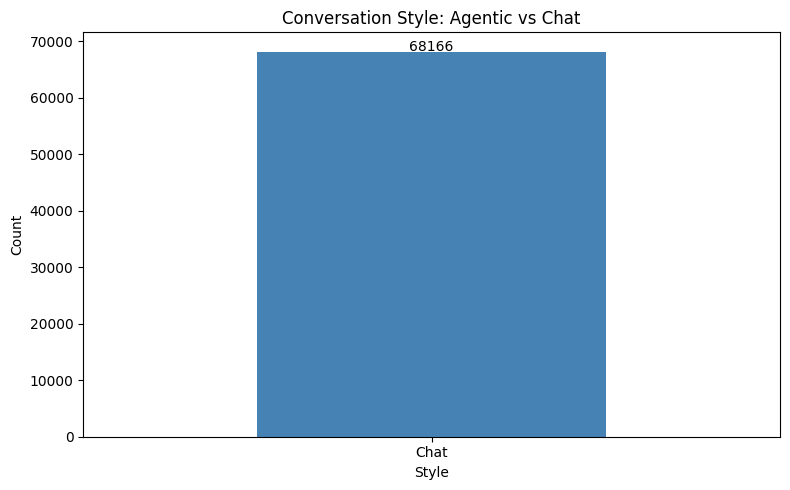

In [14]:
# Conversation style breakdown: Agentic vs Chat
df['conversation_style'] = df['scaffold'].apply(lambda x: 'Agentic' if x is not None else 'Chat')

style_counts = df['conversation_style'].value_counts()
print("Conversation Style Breakdown:")
print(style_counts)
print(f"\nTotal: {style_counts.sum()}")

# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
style_counts.plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
ax.set_title('Conversation Style: Agentic vs Chat')
ax.set_xlabel('Style')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(style_counts.values):
    ax.text(i, v + 100, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 2. Eval Category Breakdown: Non-evals, Capability, Alignment

- **Non-evals**: `eval_category == False` (organic/real conversations)
- **Capability evals**: `eval_category == True` AND `eval_type == 'capability'`
- **Alignment evals**: `eval_category == True` AND `eval_type == 'alignment'`

Combined Breakdown:
Non-evals           29211
Capability evals     7273
Alignment evals     31682
dtype: int64

Total: 68166


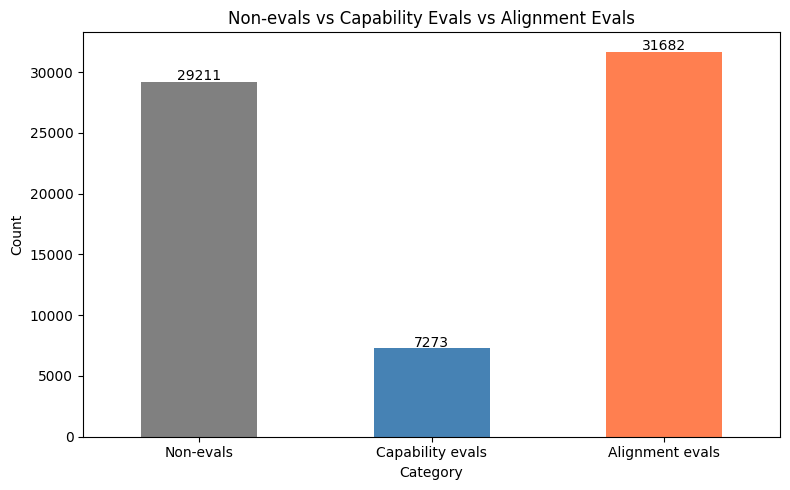

In [15]:
# Combined breakdown: Non-evals, Capability evals, Alignment evals
non_evals = df[df['eval_category'] == False]
capability_evals = df[(df['eval_category'] == True) & (df['eval_type'] == 'capability')]
alignment_evals = df[(df['eval_category'] == True) & (df['eval_type'] == 'alignment')]

combined_counts = pd.Series({
    'Non-evals': len(non_evals),
    'Capability evals': len(capability_evals),
    'Alignment evals': len(alignment_evals)
})

print("Combined Breakdown:")
print(combined_counts)
print(f"\nTotal: {combined_counts.sum()}")

# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
combined_counts.plot(kind='bar', ax=ax, color=['gray', 'steelblue', 'coral'])
ax.set_title('Non-evals vs Capability Evals vs Alignment Evals')
ax.set_xlabel('Category')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(combined_counts.values):
    ax.text(i, v + 100, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 3. Breakdown by `eval_category`

In [16]:
# eval_category breakdown
eval_category_counts = df['eval_category'].value_counts(dropna=False)
print("eval_category breakdown:")
print(eval_category_counts)
print(f"\nTotal: {eval_category_counts.sum()}")

eval_category breakdown:
eval_category
True     38955
False    29211
Name: count, dtype: int64

Total: 68166


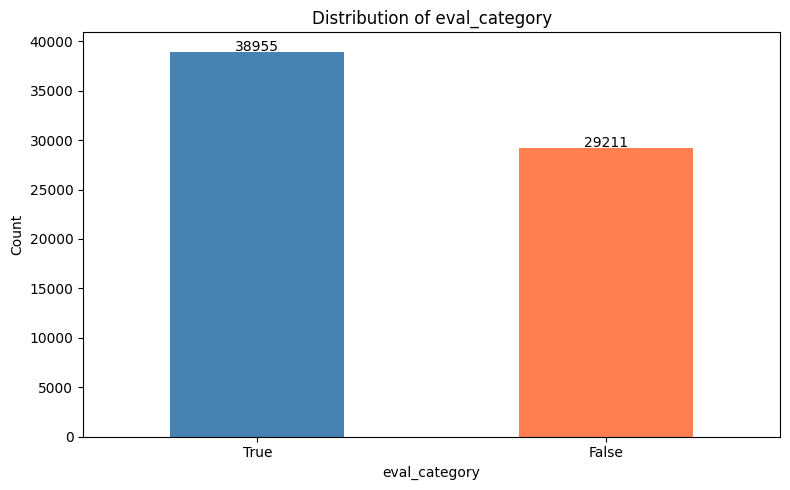

In [17]:
# Visualize eval_category
fig, ax = plt.subplots(figsize=(8, 5))
eval_category_counts.plot(kind='bar', ax=ax, color=['steelblue', 'coral', 'gray'])
ax.set_title('Distribution of eval_category')
ax.set_xlabel('eval_category')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(eval_category_counts.values):
    ax.text(i, v + 100, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 4. Breakdown by `eval_type`

In [18]:
# eval_type breakdown
eval_type_counts = df['eval_type'].value_counts(dropna=False)
print("eval_type breakdown:")
print(eval_type_counts)
print(f"\nTotal: {eval_type_counts.sum()}")

eval_type breakdown:
eval_type
alignment     31682
              29211
capability     7273
Name: count, dtype: int64

Total: 68166


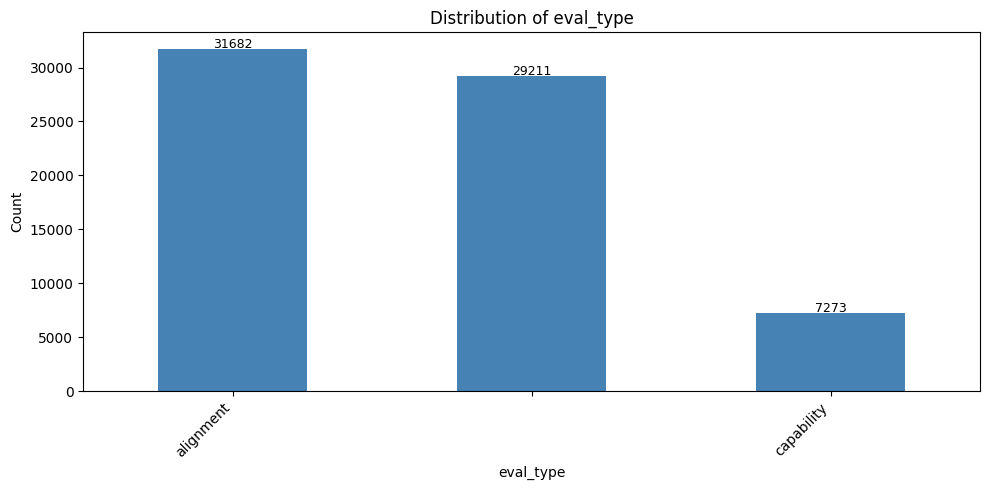

In [19]:
# Visualize eval_type
fig, ax = plt.subplots(figsize=(10, 5))
eval_type_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Distribution of eval_type')
ax.set_xlabel('eval_type')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
for i, v in enumerate(eval_type_counts.values):
    ax.text(i, v + 100, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 5. Breakdown by Benchmark (from `id` field)

In [20]:
# Benchmark breakdown
benchmark_counts = df['benchmark'].value_counts()
print(f"Number of unique benchmarks: {len(benchmark_counts)}")
print("\nTranscripts per benchmark:")
print(benchmark_counts)
print(f"\nTotal: {benchmark_counts.sum()}")

Number of unique benchmarks: 38

Transcripts per benchmark:
benchmark
toxic_chat                     3000
prosocial_dialog               3000
hh_rlhf                        3000
hackaprompt_dataset            3000
researchy_questions            3000
sharegpt                       3000
prism                          3000
toxigen_data                   3000
cdial_bias                     3000
safetybench                    2000
model_written_evals            2000
gest                           2000
cvalues_rlhf                   2000
real_toxicity_prompts          2000
mmlu                           2000
s_eval                         2000
or_bench                       2000
nl2bash                        2000
ultrasafety                    2000
natural_reasoning              2000
kobbq                          2000
ethics                         2000
aya_redteaming                 2000
llm_global_opinions            2000
mosscap_prompt_injection       2000
discrim_eval                  

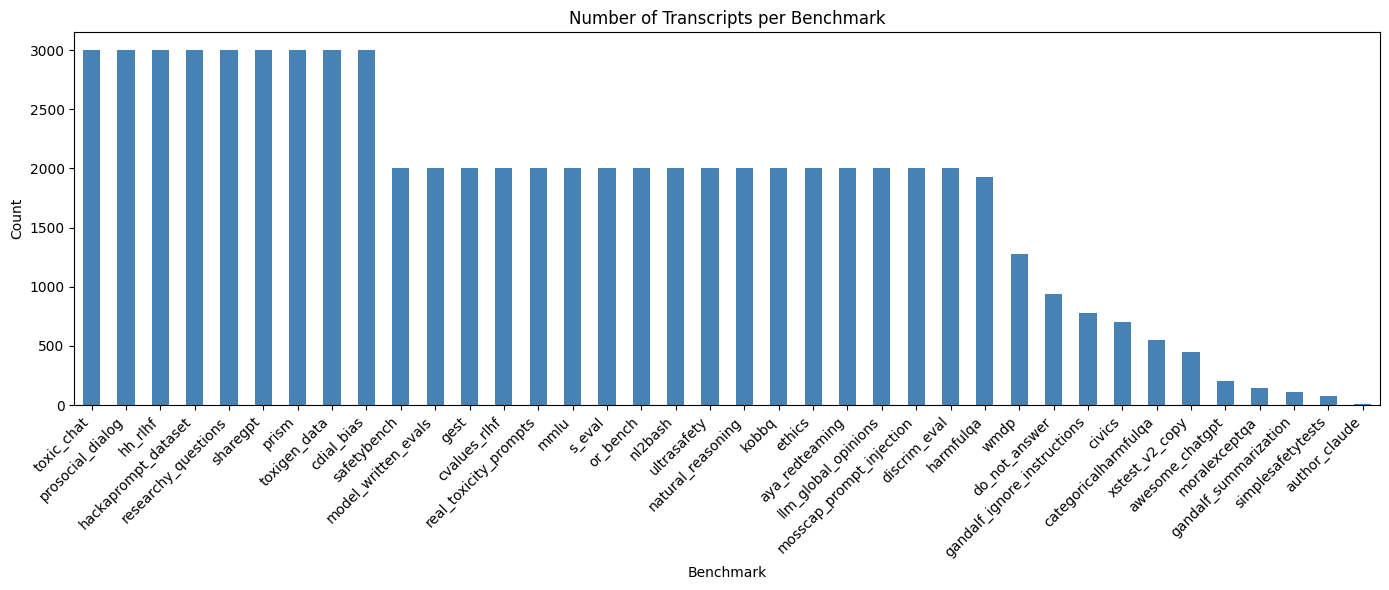

In [21]:
# Visualize benchmark distribution
fig, ax = plt.subplots(figsize=(14, 6))
benchmark_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Number of Transcripts per Benchmark')
ax.set_xlabel('Benchmark')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [22]:
# Summary table
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"\nTotal transcripts: {len(df)}")
print(f"Unique benchmarks: {df['benchmark'].nunique()}")

print(f"\nConversation Style:")
for style, count in style_counts.items():
    pct = count / len(df) * 100
    print(f"  {style}: {count} ({pct:.1f}%)")

print(f"\nEval Category Breakdown:")
print(f"  Non-evals: {len(non_evals)} ({len(non_evals)/len(df)*100:.1f}%)")
print(f"  Capability evals: {len(capability_evals)} ({len(capability_evals)/len(df)*100:.1f}%)")
print(f"  Alignment evals: {len(alignment_evals)} ({len(alignment_evals)/len(df)*100:.1f}%)")

SUMMARY

Total transcripts: 68166
Unique benchmarks: 38

Conversation Style:
  Chat: 68166 (100.0%)

Eval Category Breakdown:
  Non-evals: 29211 (42.9%)
  Capability evals: 7273 (10.7%)
  Alignment evals: 31682 (46.5%)
